<a href="https://colab.research.google.com/github/Thulasi604/ML-PROJECT/blob/main/Day6(Unsupervised__learning_and_kMeans_cluster).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
url="https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"


In [ ]:
df=pd.read_csv(url)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


<Axes: >

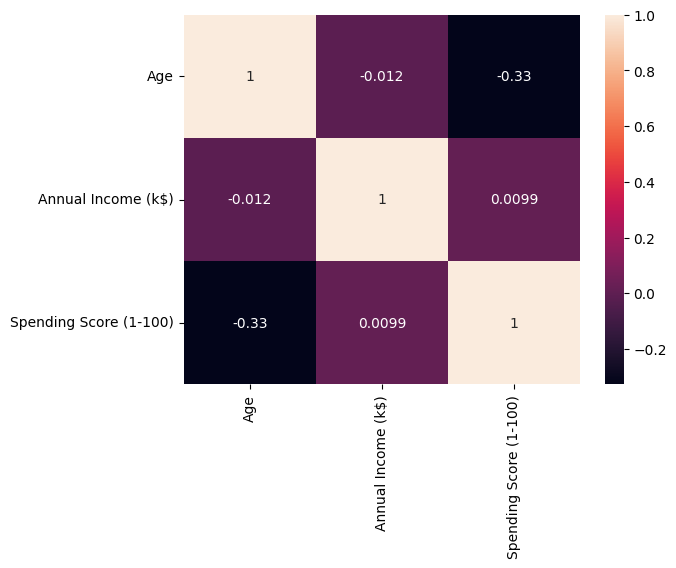

In [ ]:
data=df.drop(columns=['CustomerID','Gender'])
sns.heatmap(data.corr(),annot=True)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

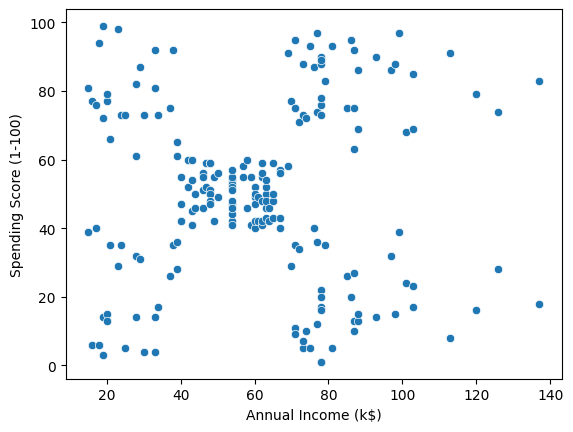

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)')


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(data.drop(columns=['Age']))


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss=[]
sil_scores=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,random_state=42,init='k-means++',max_iter=100,n_init=10)
  kmeans.fit_predict(x_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(x_scaled,labels)
  sil_scores.append(sil_h)







In [ ]:
for i,k in enumerate(range(2,11)):
  print(f"for k={k},wcss={wcss[i]:.2f}and sil_score={sil_scores[i]:.2f}")

for k=2,wcss=269.69and sil_score=0.32
for k=3,wcss=157.70and sil_score=0.47
for k=4,wcss=108.92and sil_score=0.49
for k=5,wcss=65.57and sil_score=0.55
for k=6,wcss=55.06and sil_score=0.54
for k=7,wcss=44.86and sil_score=0.53
for k=8,wcss=37.23and sil_score=0.46
for k=9,wcss=32.39and sil_score=0.46
for k=10,wcss=29.98and sil_score=0.44


Text(0, 0.5, 'Silhouette Score')

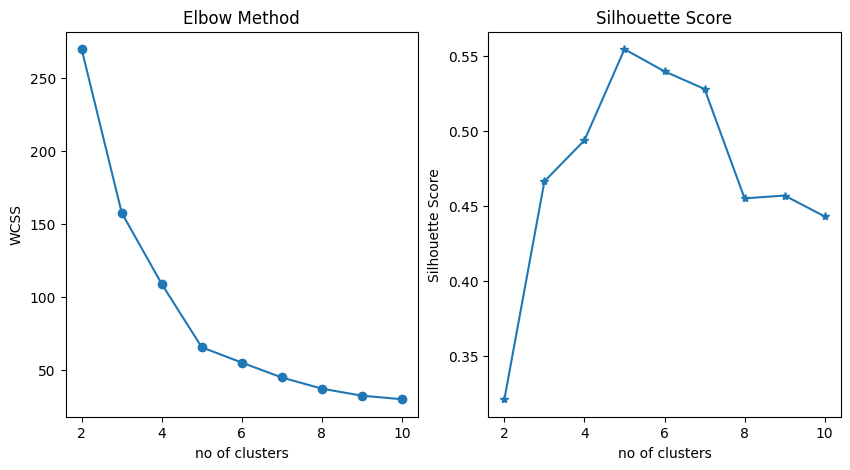

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("no of clusters")
plt.ylabel("WCSS")

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title("Silhouette Score")
plt.xlabel("no of clusters")
plt.ylabel("Silhouette Score")

In [ ]:
from sklearn import cluster
kmeans=KMeans(n_clusters=5,random_state=42,init='k-means++',max_iter=100,n_init=10)
kmeans.fit(x_scaled)
cluster_labels=kmeans.predict(x_scaled)
cluster_labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
df['kmeans_clusters']=cluster_labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),kmeans_clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
df['kmeans_clusters'].value_counts()

,count
kmeans_clusters,
0,81
1,39
3,35
4,23
2,22


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

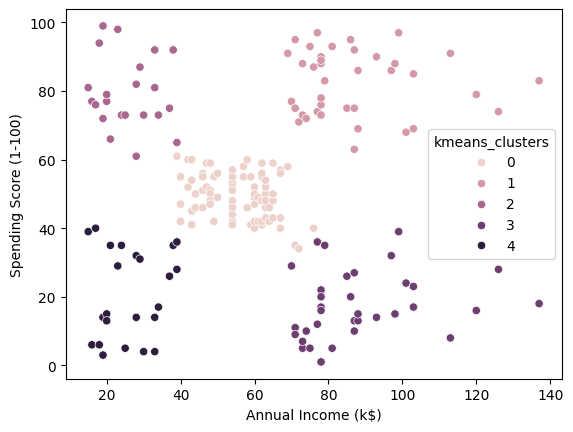

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='kmeans_clusters')


In [ ]:
new_customer=np.array([[45,60]])
scaled=scaler.transform(new_customer)
cluster=kmeans.predict(scaled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int32)

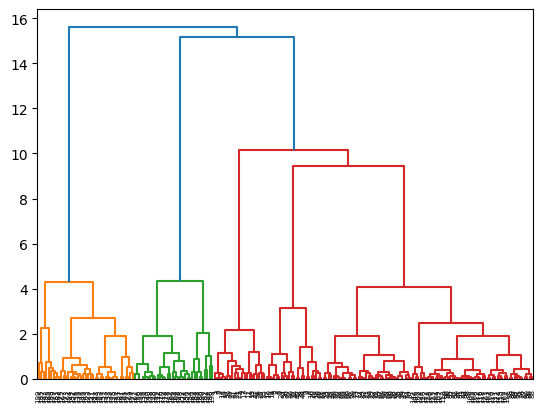

In [ ]:
from scipy.cluster.hierarchy import dendrogram,linkage

mergings=linkage(x_scaled,method='ward')
dendrogram(mergings);

In [ ]:
from scipy.cluster.hierarchy import fcluster
cluster_labels=fcluster(mergings,4,criterion='maxclust')
cluster_labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 4, 1, 4, 1, 2, 1, 2, 1,
       4, 1, 2, 1, 2, 1, 2, 1, 2, 1, 4, 1, 2, 1, 4, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 4, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(x_scaled)
agg_cluster

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [ ]:
df['agg_cluster']=agg_cluster
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),kmeans_clusters,agg_cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,4,4


In [ ]:
df['agg_cluster'].value_counts()

,count
agg_cluster,
2,85
1,39
0,32
4,23
3,21


In [ ]:
df.kmeans_clusters.value_counts()

,count
kmeans_clusters,
0,81
1,39
3,35
4,23
2,22


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

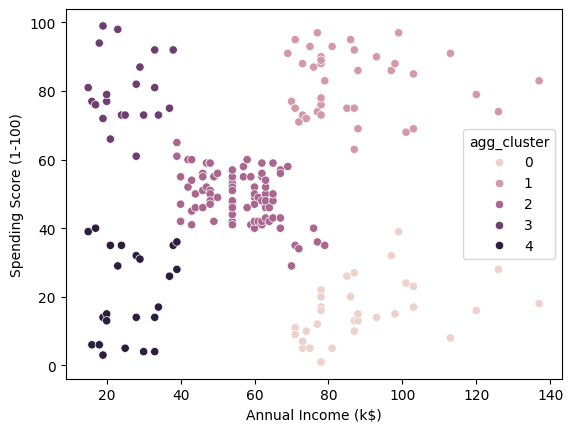

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='agg_cluster')

In [ ]:
sil_scores={}
for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=i,metric='euclidean',linkage='ward')
  sil_h=silhouette_score(x_scaled,agg_hc.fit_predict(x_scaled))
  sil_scores[i]=sil_h
sil_scores





{2: np.float64(0.3842337621772661),
 3: np.float64(0.4610481446570447),
 4: np.float64(0.4925507715349343),
 5: np.float64(0.5538089226688662),
 6: np.float64(0.5386761871036926),
 7: np.float64(0.5197949293475768),
 8: np.float64(0.4308617778221774),
 9: np.float64(0.43768997758154127),
 10: np.float64(0.4339007174968657)}

In [ ]:
from sklearn.cluster import DBSCAN
db_cluster=DBSCAN(eps=0.5,min_samples=5)
db_cluster=db_cluster.fit_predict(x_scaled)
db_cluster


array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0, -1, -1,  1, -1, -1, -1, -1, -1, -1])

In [ ]:
df['db_cluster'].value_counts()

,count
db_cluster,
0,157
1,35
-1,8


In [ ]:
df['db_cluster']=db_cluster
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),kmeans_clusters,agg_cluster,db_cluster
0,1,Male,19,15,39,4,4,0
1,2,Male,21,15,81,2,3,0
2,3,Female,20,16,6,4,4,0
3,4,Female,23,16,77,2,3,0
4,5,Female,31,17,40,4,4,0


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

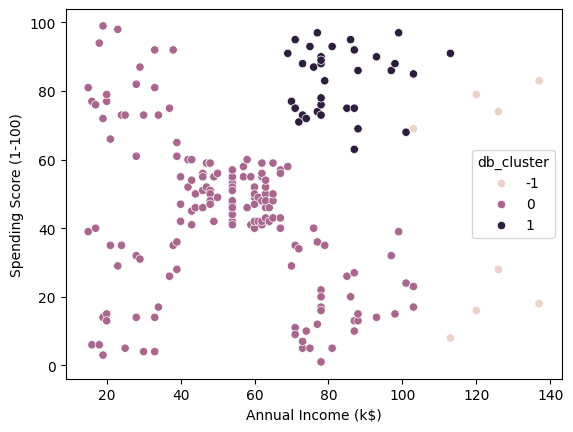

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='db_cluster')

In [ ]:
sil_scores={}
for i in range(2,11):
  db_hc=DBSCAN(eps=0.5,min_samples=5)
  sil_h=silhouette_score(x_scaled,db_hc.fit_predict(x_scaled))
  sil_scores[i]=sil_h
sil_scores

{2: np.float64(0.35044619989666004),
 3: np.float64(0.35044619989666004),
 4: np.float64(0.35044619989666004),
 5: np.float64(0.35044619989666004),
 6: np.float64(0.35044619989666004),
 7: np.float64(0.35044619989666004),
 8: np.float64(0.35044619989666004),
 9: np.float64(0.35044619989666004),
 10: np.float64(0.35044619989666004)}

In [ ]:
fish=pd.read_csv("/content/fish.csv")
fish.columns = ['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']

In [ ]:
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


In [ ]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  84 non-null     object 
 1   Weight   84 non-null     float64
 2   Length1  84 non-null     float64
 3   Length2  84 non-null     float64
 4   Length3  84 non-null     float64
 5   Height   84 non-null     float64
 6   Width    84 non-null     float64
dtypes: float64(6), object(1)
memory usage: 4.7+ KB


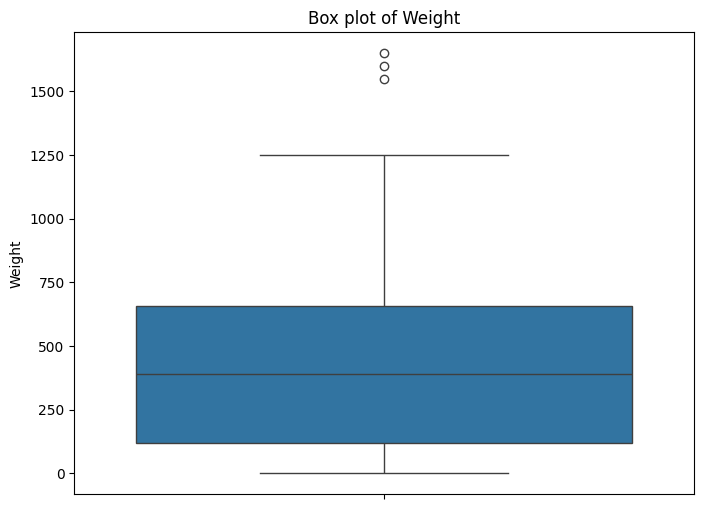

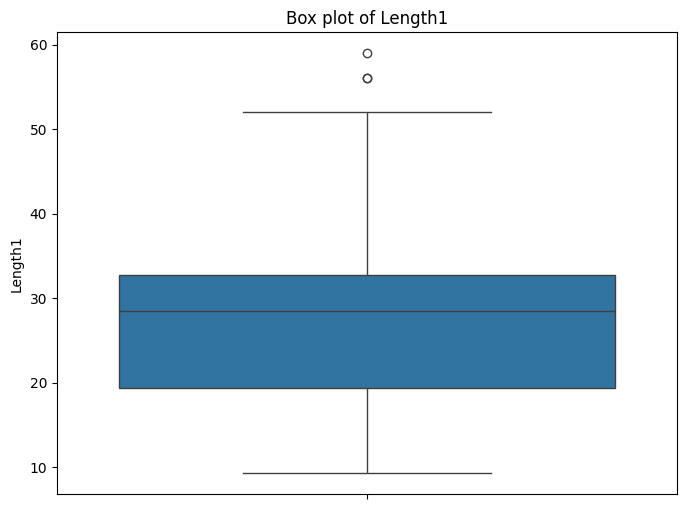

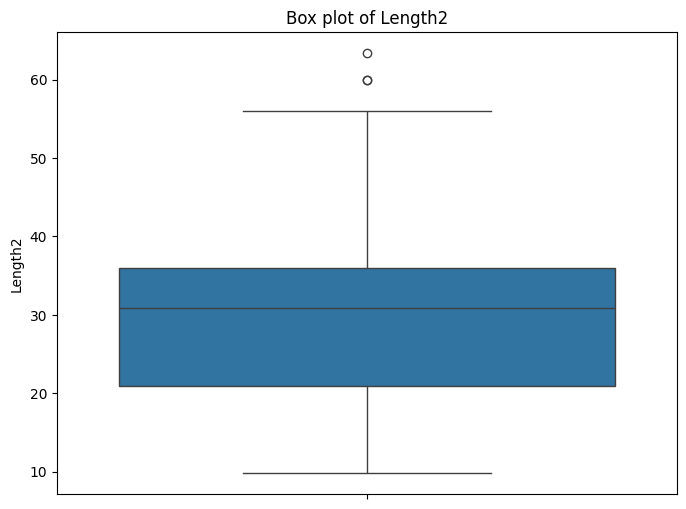

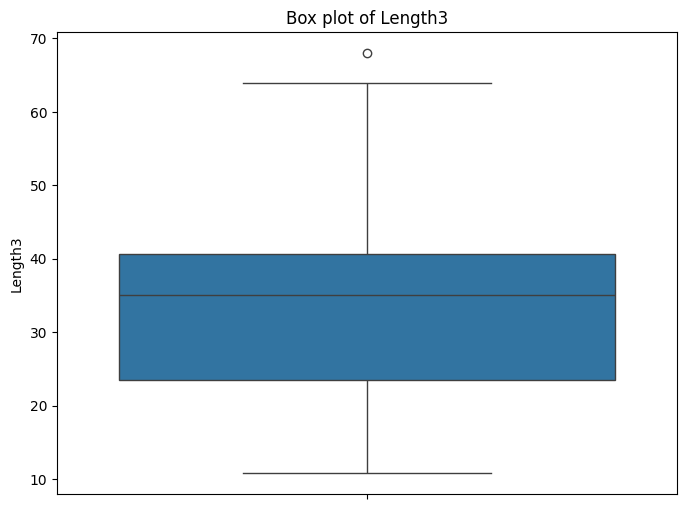

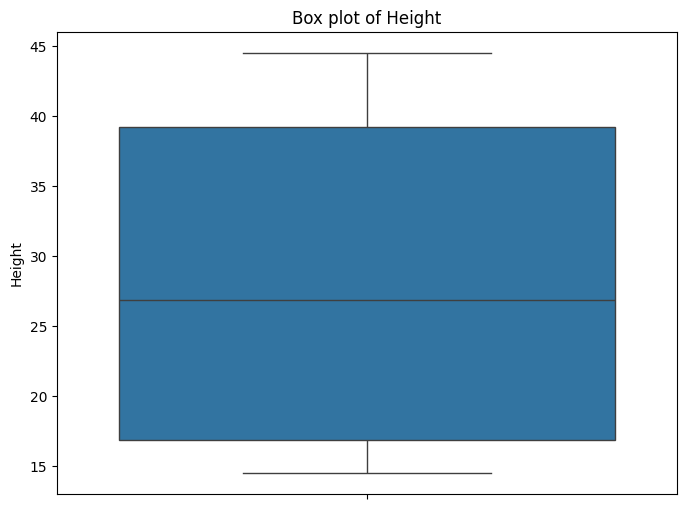

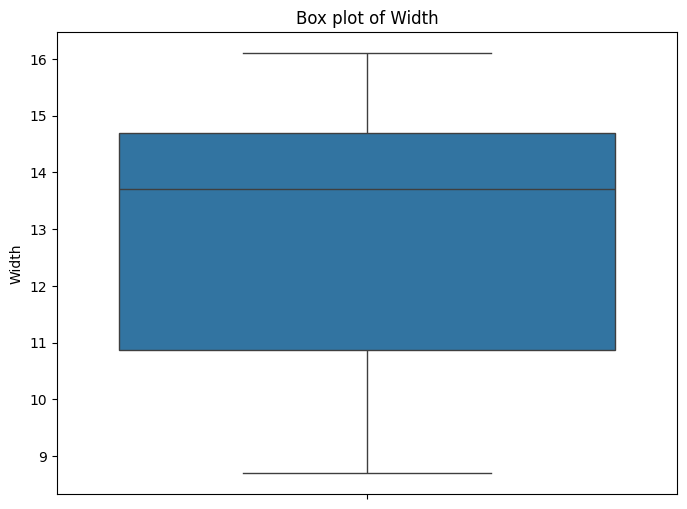

In [ ]:
numerical_cols=fish.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(8,6))
  sns.boxplot(y=fish[col])
  plt.title(f'Box plot of {col}')
  plt.show()

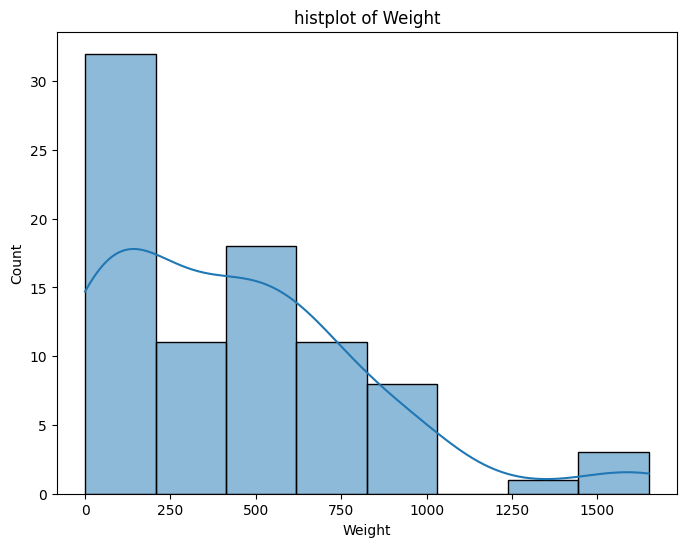

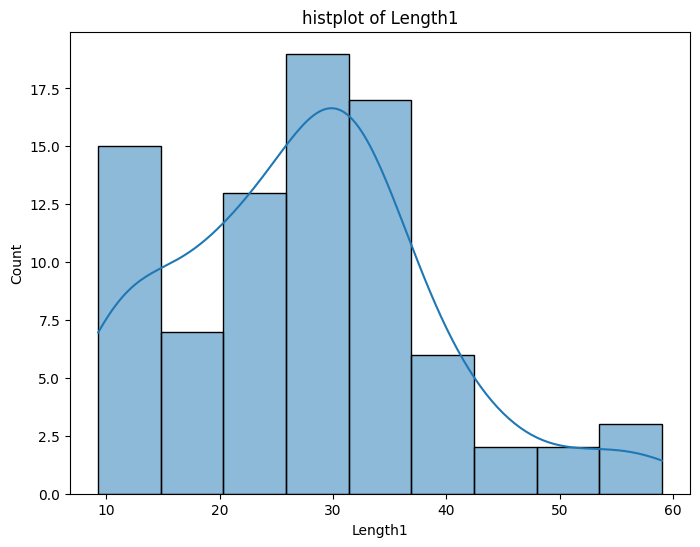

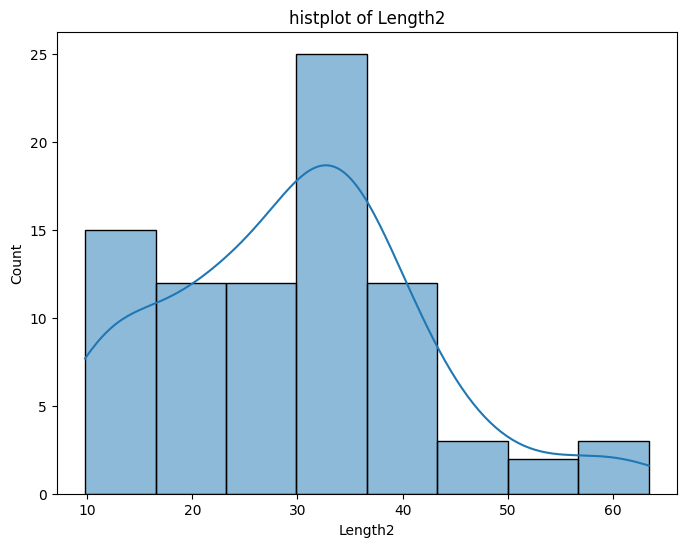

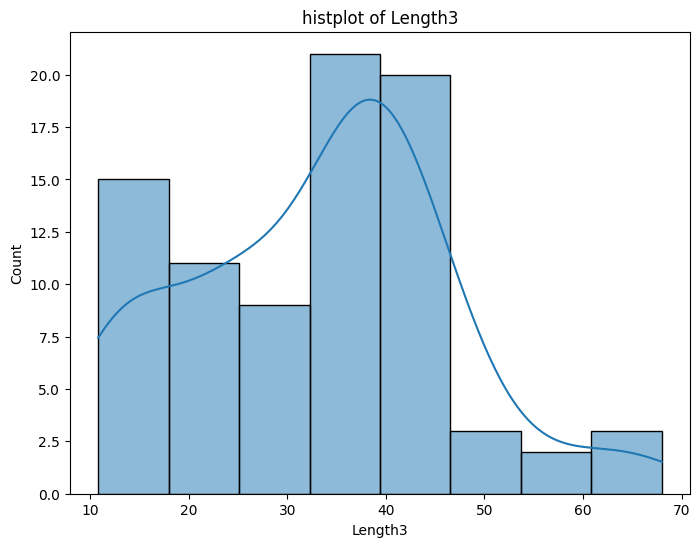

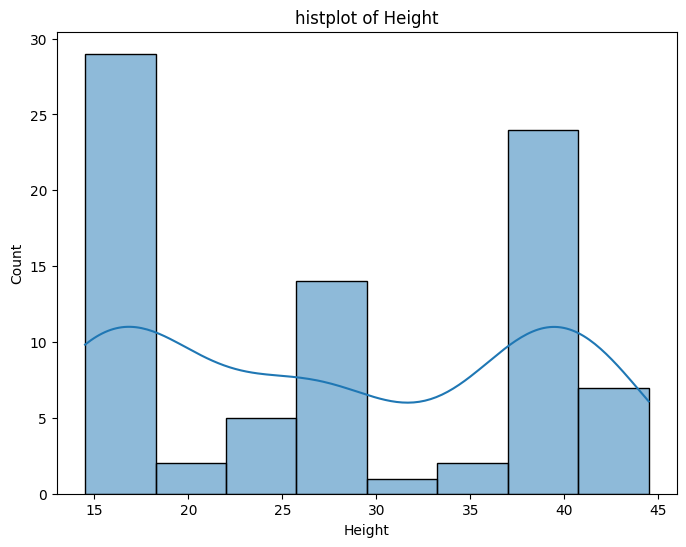

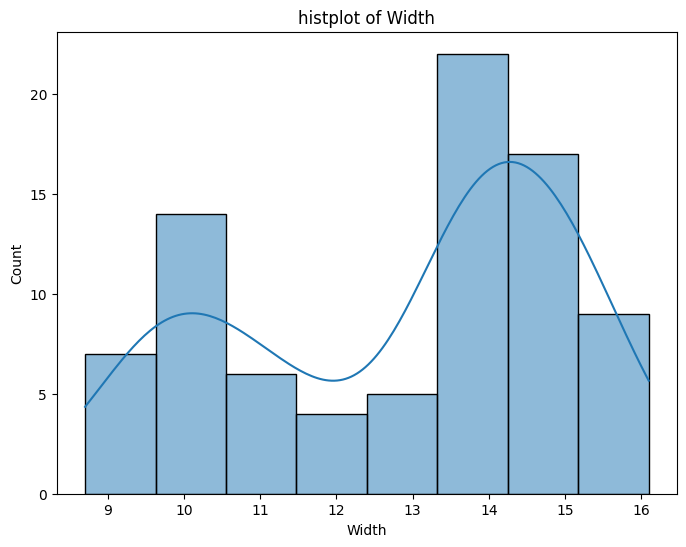

In [ ]:
import numpy as np
numerical_cols=fish.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(8,6))
  sns.histplot(fish[col],kde=True)
  plt.title(f'histplot of {col}')
  plt.show()

In [ ]:
from scipy.stats import skew
cat_values=fish.select_dtypes(include='object').columns
num_value=fish.select_dtypes(include=['int64','float64']).columns
skew_value=fish[num_value].skew()
skew_value

,0
Weight,1.093594
Length1,0.485725
Length2,0.418112
Length3,0.162470
Height,0.055153
Width,-0.494233


In [ ]:
from scipy.stats.mstats import winsorize
fish['Weight']=winsorize(fish['Weight'],limits=(0,0.04))

print("Outliers in 'weight' columns using winsorization method (5th and 95th percentiles),")
fish.head()

Outliers in 'weight' columns using winsorization method (5th and 95th percentiles),


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


<Axes: ylabel='Weight'>

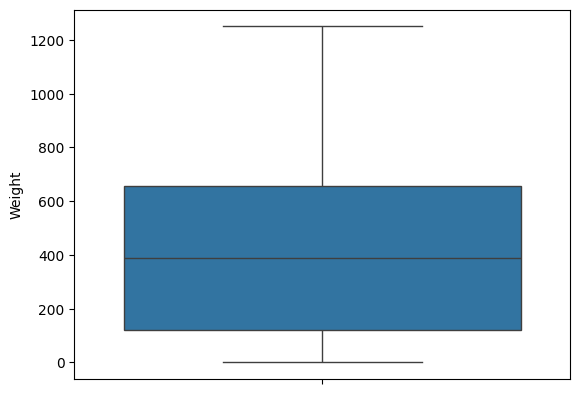

In [ ]:
sns.boxplot(y=fish['Weight'])

In [ ]:
data=fish.drop(columns=['Species'])
data


,Weight,Length1,Length2,Length3,Height,Width
0,290.0,24.0,26.3,31.2,40.0,13.8
1,340.0,23.9,26.5,31.1,39.8,15.1
2,363.0,26.3,29.0,33.5,38.0,13.3
3,430.0,26.5,29.0,34.0,36.6,15.1
4,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...
79,950.0,48.3,51.7,55.1,16.2,11.2
80,1250.0,52.0,56.0,59.7,17.9,11.7
81,1250.0,56.0,60.0,64.0,15.0,9.6
82,1250.0,56.0,60.0,64.0,15.0,9.6


<Axes: >

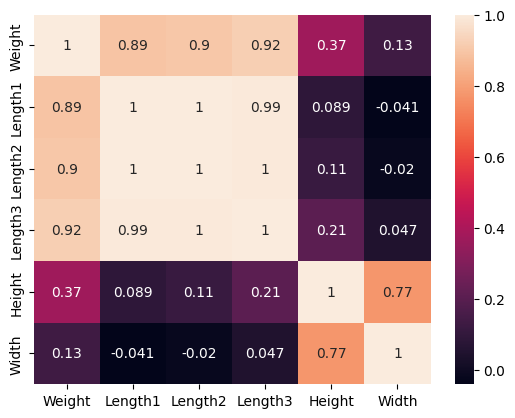

In [ ]:
sns.heatmap(data.corr(),annot=True)

<Axes: xlabel='Length1', ylabel='Weight'>

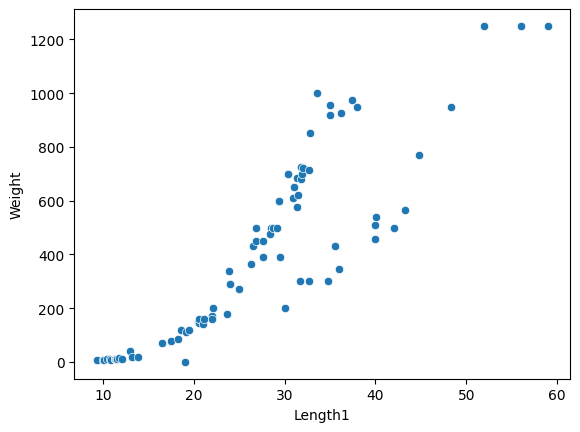

In [ ]:
sns.scatterplot(data=fish, x='Length1', y='Weight')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(data)



In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss=[]
sil_scores=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,random_state=42,init='k-means++',max_iter=100,n_init=10)
  kmeans.fit_predict(x_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(x_scaled,labels)
  sil_scores.append(sil_h)

In [ ]:
for i,k in enumerate(range(2,11)):
  print(f"for k={k},wcss={wcss[i]:.2f}and sil_score={sil_scores[i]:.2f}")

for k=2,wcss=275.09and sil_score=0.43
for k=3,wcss=147.62and sil_score=0.53
for k=4,wcss=90.35and sil_score=0.58
for k=5,wcss=50.65and sil_score=0.61
for k=6,wcss=37.06and sil_score=0.53
for k=7,wcss=31.30and sil_score=0.51
for k=8,wcss=26.15and sil_score=0.51
for k=9,wcss=22.31and sil_score=0.45
for k=10,wcss=20.17and sil_score=0.45


Text(0, 0.5, 'Silhouette Score')

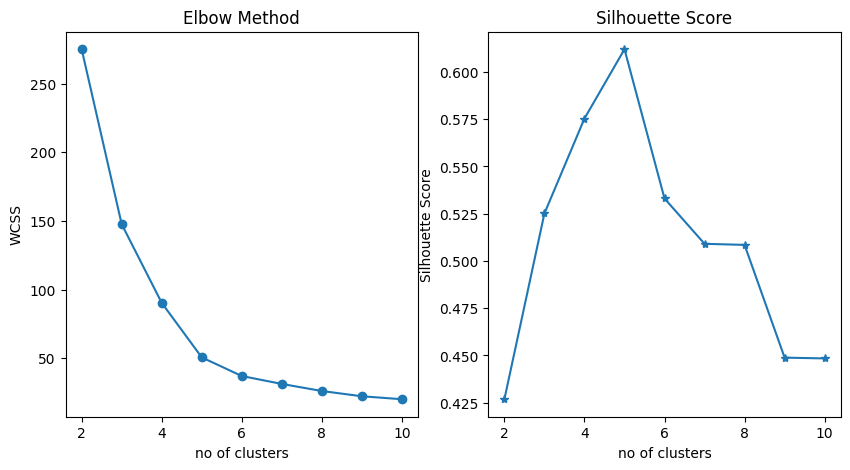

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("no of clusters")
plt.ylabel("WCSS")

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title("Silhouette Score")
plt.xlabel("no of clusters")
plt.ylabel("Silhouette Score")

In [ ]:
from sklearn import cluster
kmeans=KMeans(n_clusters=5,random_state=42,init='k-means++',max_iter=100,n_init=10)
kmeans.fit(x_scaled)
cluster_labels=kmeans.predict(x_scaled)
cluster_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4], dtype=int32)

In [ ]:
fish['kmeans_clusters']=cluster_labels
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,kmeans_clusters
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0


In [ ]:
df['kmeans_clusters'].value_counts()

,count
kmeans_clusters,
0,81
1,39
3,35
4,23
2,22


<Axes: xlabel='Length1', ylabel='Weight'>

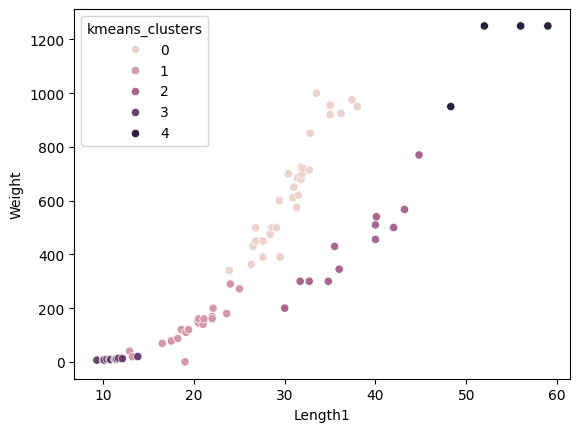

In [ ]:
sns.scatterplot(data=fish, x='Length1', y='Weight',hue='kmeans_clusters')

In [ ]:
new_fish=np.array([[25,300,20,20,20,20]])
scaled=scaler.transform(new_fish)
cluster=kmeans.predict(scaled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

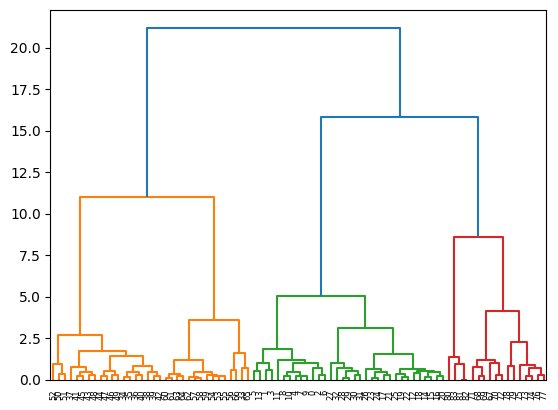

In [ ]:
from scipy.cluster.hierarchy import dendrogram,linkage

mergings=linkage(x_scaled,method='ward')
dendrogram(mergings);

In [ ]:
from scipy.cluster.hierarchy import fcluster
cluster_labels=fcluster(mergings,4,criterion='maxclust')
cluster_labels

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype=int32)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg_hc=AgglomerativeClustering(n_clusters=4,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(x_scaled)
agg_cluster

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4])

In [ ]:
fish['agg_cluster']=agg_cluster
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,kmeans_clusters,agg_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0,0
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0,0
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0,0
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0,0
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0,0


In [ ]:
fish['agg_cluster'].value_counts()

,count
agg_cluster,
0,33
3,19
1,15
2,13
4,4


In [ ]:
fish['kmeans_clusters'].value_counts()

,count
kmeans_clusters,
0,34
1,20
3,13
2,12
4,5


<Axes: xlabel='Weight', ylabel='Length1'>

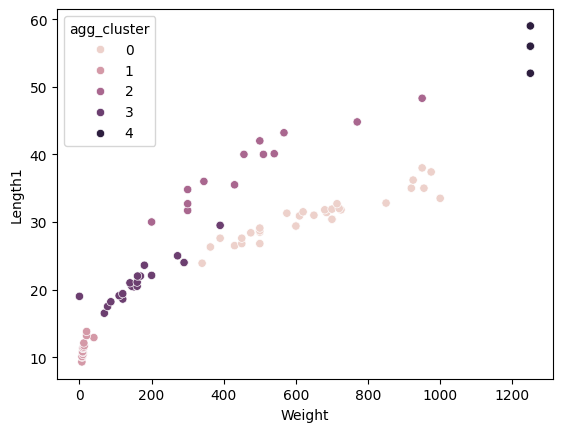

In [ ]:
sns.scatterplot(data=fish,x='Weight',y='Length1',hue='agg_cluster')

In [ ]:
sil_scores={}
for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=i,metric='euclidean',linkage='ward')
  sil_h=silhouette_score(x_scaled,agg_hc.fit_predict(x_scaled))
  sil_scores[i]=sil_h
sil_scores

{2: np.float64(0.41964947702752153),
 3: np.float64(0.5170541327797996),
 4: np.float64(0.5492292994390172),
 5: np.float64(0.579524052722487),
 6: np.float64(0.50111584276039),
 7: np.float64(0.4889048687933653),
 8: np.float64(0.46439336252633),
 9: np.float64(0.4645756765999127),
 10: np.float64(0.44961755919571483)}

In [ ]:
from sklearn.cluster import DBSCAN
db_cluster=DBSCAN(eps=0.5,min_samples=5)
db_cluster=db_cluster.fit_predict(x_scaled)
db_cluster


array([-1, -1,  0, -1,  0, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  1,  1,  1, -1, -1,
        2,  2,  2, -1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
       -1, -1,  3,  3,  3, -1,  3,  3,  3,  3,  3,  3,  3,  3, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
fish['db_cluster']=db_cluster
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,kmeans_clusters,agg_cluster,db_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0,0,-1
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0,0,-1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0,0,0
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0,0,-1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0,0,0


<Axes: xlabel='Weight', ylabel='Length1'>

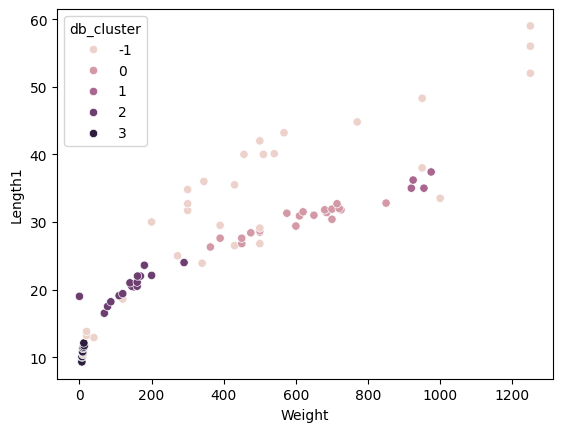

In [ ]:
sns.scatterplot(data=fish,x='Weight',y='Length1',hue='db_cluster')

In [ ]:
sil_scores={}
for i in range(2,11):
  db_hc=DBSCAN(eps=0.5,min_samples=5)
  sil_h=silhouette_score(x_scaled,db_hc.fit_predict(x_scaled))
  sil_scores[i]=sil_h
sil_scores

{2: np.float64(0.297634652141464),
 3: np.float64(0.297634652141464),
 4: np.float64(0.297634652141464),
 5: np.float64(0.297634652141464),
 6: np.float64(0.297634652141464),
 7: np.float64(0.297634652141464),
 8: np.float64(0.297634652141464),
 9: np.float64(0.297634652141464),
 10: np.float64(0.297634652141464)}